## HW01-ICA :: Part B
### Adam Nelson-Archer, 2140122

All paths are relative to this notebook location (`Part B/`).


In [12]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

try:
    import cv2
except ImportError as e:
    raise ImportError(
        "OpenCV is not installed."
    ) from e

print("cv2 version:", cv2.__version__)


cv2 version: 4.10.0


## (a) Load image (BGR), convert to RGB, plot with Matplotlib


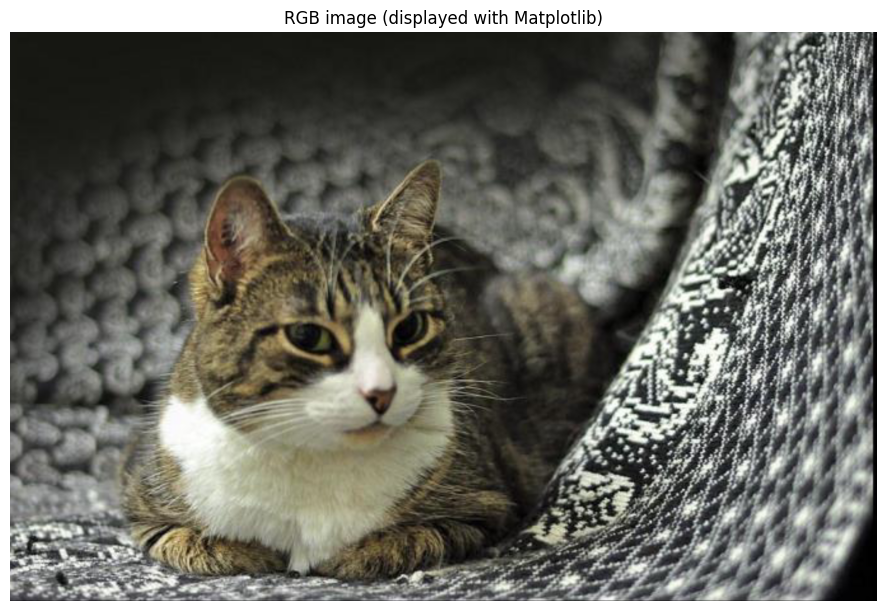

In [13]:
# Here we load image 
# OpenCV reads color images as BGR by default

img_path = Path("cat.png")

bgr = cv2.imread(str(img_path), cv2.IMREAD_COLOR)
if bgr is None:
    raise ValueError("cv2.imread returned None. The file may be unreadable or corrupted.")

rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

fig, ax = plt.subplots(1, 1, figsize=(9, 6), constrained_layout=True)
ax.imshow(rgb)
ax.set_title("RGB image (displayed with Matplotlib)")
ax.axis("off")
plt.show()


## (b) Print pixels, height, width, channels (color image)


In [14]:
h, w, c = bgr.shape
num_pixels = h * w

print("Loaded:", img_path)
print("Number of pixels:", num_pixels)
print("Height:", h)
print("Width:", w)
print("Channels:", c)


Loaded: cat.png
Number of pixels: 1762488
Height: 1076
Width: 1638
Channels: 3


## (c) Isolate Red, Green, Blue channels and plot them


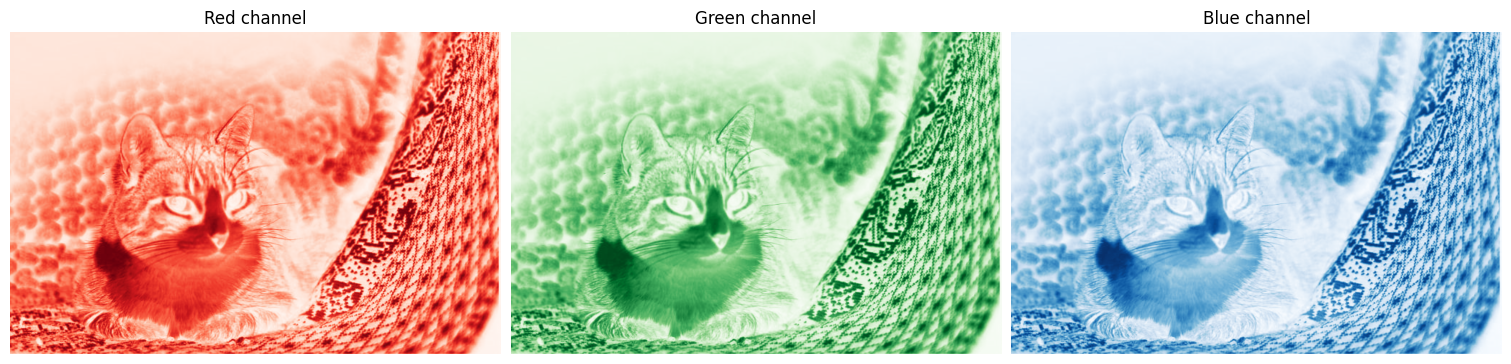

In [15]:
# rgb is HxWx3 with channels ordered [R, G, B]
r = rgb[:, :, 0]
g = rgb[:, :, 1]
b = rgb[:, :, 2]

fig, ax = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)
ax[0].imshow(r, cmap="Reds")
ax[0].set_title("Red channel")
ax[0].axis("off")

ax[1].imshow(g, cmap="Greens")
ax[1].set_title("Green channel")
ax[1].axis("off")

ax[2].imshow(b, cmap="Blues")
ax[2].set_title("Blue channel")
ax[2].axis("off")

plt.show()


## (d) Compute and plot unnormalized histograms for R, G, B channels


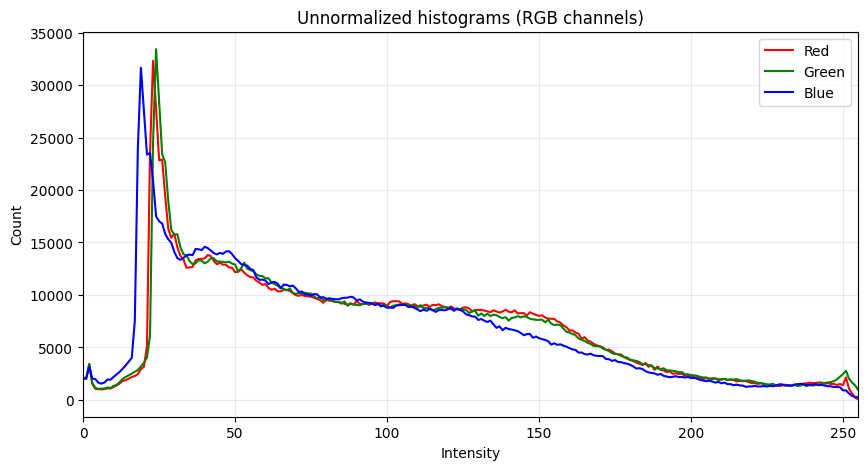

In [16]:
# Unnormalized histogram: raw counts per intensity bin
hist_r = cv2.calcHist([r], [0], None, [256], [0, 256]).ravel()
hist_g = cv2.calcHist([g], [0], None, [256], [0, 256]).ravel()
hist_b = cv2.calcHist([b], [0], None, [256], [0, 256]).ravel()

x = np.arange(256)

plt.figure(figsize=(10, 5))
plt.plot(x, hist_r, color="red", label="Red")
plt.plot(x, hist_g, color="green", label="Green")
plt.plot(x, hist_b, color="blue", label="Blue")
plt.title("Unnormalized histograms (RGB channels)")
plt.xlabel("Intensity")
plt.ylabel("Count")
plt.xlim(0, 255)
plt.legend()
plt.grid(alpha=0.25)
plt.show()


## (e) Convert to grayscale and plot


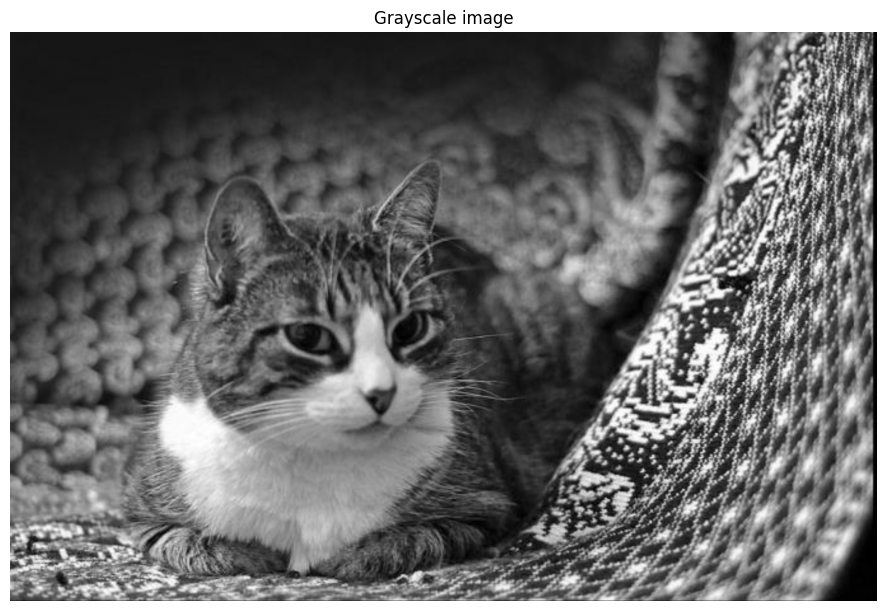

In [17]:
gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)

fig, ax = plt.subplots(1, 1, figsize=(9, 6), constrained_layout=True)
ax.imshow(gray, cmap="gray")
ax.set_title("Grayscale image")
ax.axis("off")
plt.show()


## (f) Print pixels, height, width, channels (grayscale image)


In [18]:
h_g, w_g = gray.shape
num_pixels_g = h_g * w_g
channels_g = 1

print("Number of pixels:", num_pixels_g)
print("Height:", h_g)
print("Width:", w_g)
print("Channels:", channels_g)


Number of pixels: 1762488
Height: 1076
Width: 1638
Channels: 1


## (g) Compute and plot unnormalized histogram (grayscale)


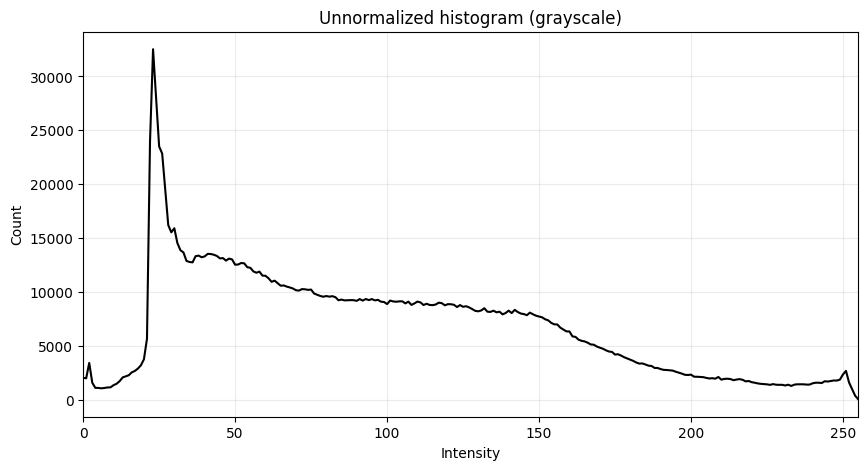

In [19]:
hist_gray = cv2.calcHist([gray], [0], None, [256], [0, 256]).ravel()

x = np.arange(256)
plt.figure(figsize=(10, 5))
plt.plot(x, hist_gray, color="black")
plt.title("Unnormalized histogram (grayscale)")
plt.xlabel("Intensity")
plt.ylabel("Count")
plt.xlim(0, 255)
plt.grid(alpha=0.25)
plt.show()


## (h) Apply a binary threshold and plot


Threshold value used: 128
Unique values in thresholded image: [  0 255]


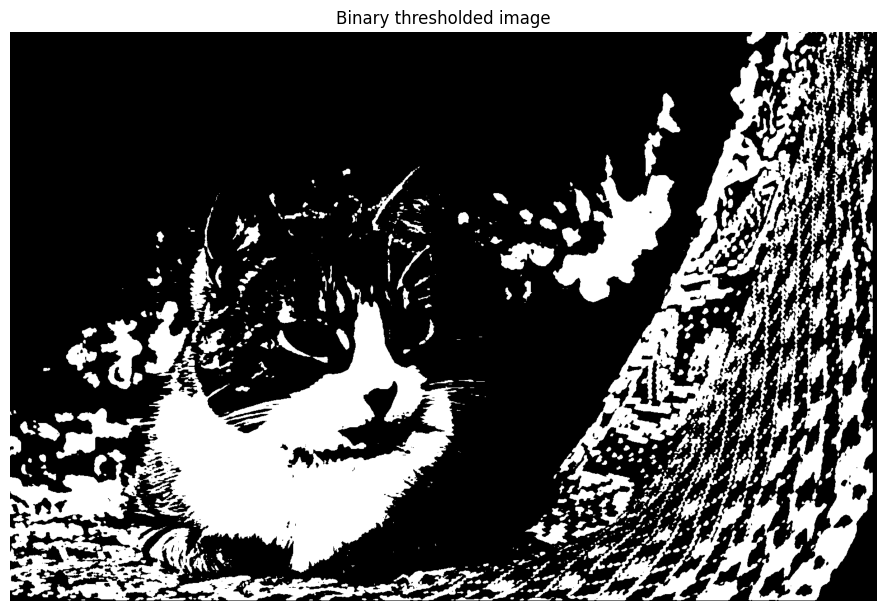

In [24]:
# This threshold was chosen arbitrarily, it could change
threshold_value = 128
_, thresh = cv2.threshold(gray, threshold_value, 255, cv2.THRESH_BINARY)

print("Threshold value used:", threshold_value)
print("Unique values in thresholded image:", np.unique(thresh))

fig, ax = plt.subplots(1, 1, figsize=(9, 6), constrained_layout=True)
ax.imshow(thresh, cmap="gray")
ax.set_title("Binary thresholded image")
ax.axis("off")
plt.show()


## (i) Compute and plot unnormalized histogram (thresholded image)


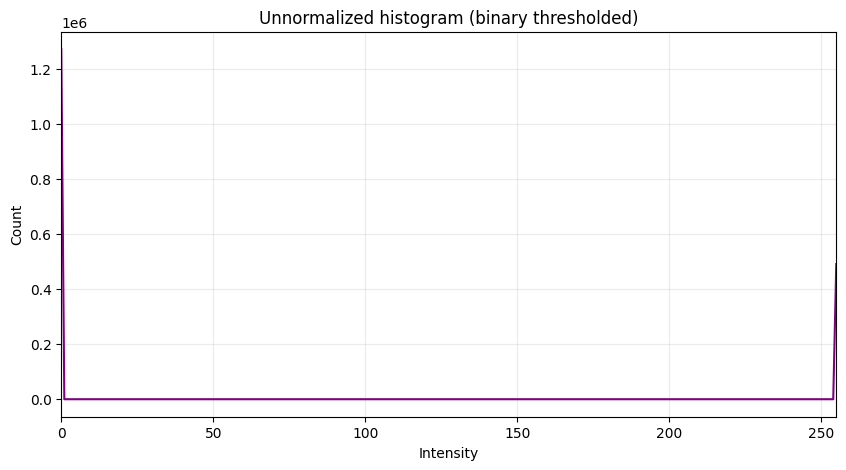

In [25]:
hist_thresh = cv2.calcHist([thresh], [0], None, [256], [0, 256]).ravel()

x = np.arange(256)
plt.figure(figsize=(10, 5))
plt.plot(x, hist_thresh, color="purple")
plt.title("Unnormalized histogram (binary thresholded)")
plt.xlabel("Intensity")
plt.ylabel("Count")
plt.xlim(0, 255)
plt.grid(alpha=0.25)
plt.show()


## (j) Commentary

### (1) Differences in the histograms for the different color channels

The three color histograms look similar in shape, but they are clearly not the same. Each channel has peaks in different intensity ranges, which shows that the image does not use red, green, and blue equally. Some parts of the image contribute more to certain colors than others.

- The red channel shows higher values in areas like the cat’s fur and warm-toned regions.
- The green channel is more influenced by the sofa texture and background patterns.
- The blue channel tends to have lower overall intensities and different peak positions because fewer parts of the image are blue.

Even though all three channels come from the same image, they represent different color information, so their histograms end up looking different.

### (2) Is converting to grayscale the same as isolating a color channel? Yes/No and why?

No. They are fundamentally different operations. Isolating a color channel means selecting only one component (R, G, or B) and discarding the others, while grayscale conversion computes a weighted combination of all three channels to represent perceived brightness.

In OpenCV, grayscale is computed approximately as:

$$
Y = 0.299R + 0.587G + 0.114B
$$

Grayscale preserves luminance information from all channels, while a single color channel only represents one spectral component. Simply put, grayscale encodes brightness, not color.

### (3) Differences between the grayscale histogram and the thresholded histogram

The grayscale histogram shows a smooth spread of values from dark to light across the full range of intensities. This makes sense because the grayscale image still contains all the different brightness levels in the picture, just without color.

The thresholded histogram looks completely different. Instead of a smooth distribution, it only has two big spikes: one at 0 (black) and one at 255 (white). This is because thresholding turns every pixel into one of only two values depending on whether it is below or above the threshold.

Thresholding is a binary operation. It does:

$$
I(x) =
\begin{cases}
0 & \text{if } I < T \\
255 & \text{if } I \ge T
\end{cases}
$$


All the gradual brightness differences that exist in the grayscale image are lost, and the image is reduced to a simple black-and-white version.


## Notes of AI usage

OpenAI's GPT-5.2 model was used to review this code after it was written by a human (me, Adam Nelson-Archer).

The import checking cell was generated by GPT-5.2.

GPT-5.2 was used to revise the commentary provided (part j) for grammar and correctness.